In [59]:
import os
os.getcwd()
import matplotlib.pyplot as plt

In [4]:
import os

base = "healthcare_project"

os.makedirs(f"{base}/data", exist_ok=True)
os.makedirs(f"{base}/notebooks", exist_ok=True)
os.makedirs(f"{base}/sql", exist_ok=True)
os.makedirs(f"{base}/visuals", exist_ok=True)

print("Project created at:", os.path.abspath(base))

Project created at: /Users/godricccc/healthcare_project


In [5]:
os.listdir("healthcare_project")


['visuals', 'data', 'notebooks', 'sql']

In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

df.to_csv("healthcare_project/data/diabetes.csv", index=False)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.shape

(768, 9)

In [9]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: >

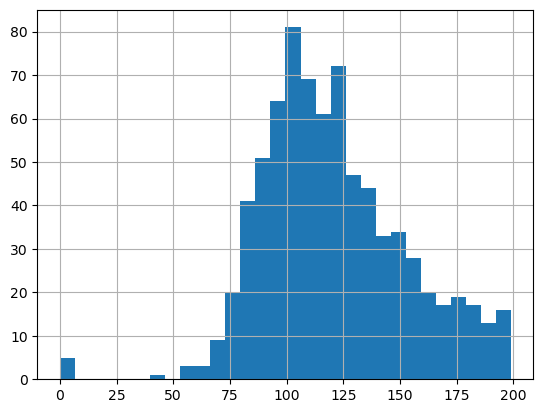

In [13]:
df["Glucose"].hist(bins=30)


In [14]:
#Most value are concentrated around 75-150, with a long tail on the high end.
#A subset of patient has significantly higher glucose levels, which may indicate potential diabetes risk.

In [15]:
df[df['Glucose']>150]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,8,183,64,0,0,23.3,0.672,32,1
8,2,197,70,45,543,30.5,0.158,53,1
11,10,168,74,0,0,38.0,0.537,34,1
13,1,189,60,23,846,30.1,0.398,59,1
14,5,166,72,19,175,25.8,0.587,51,1
...,...,...,...,...,...,...,...,...,...
749,6,162,62,0,0,24.3,0.178,50,1
753,0,181,88,44,510,43.3,0.222,26,1
754,8,154,78,32,0,32.4,0.443,45,1
759,6,190,92,0,0,35.5,0.278,66,1


In [17]:
(df['Glucose']>150).mean()

0.18229166666666666

In [18]:
#This calculates the porportion of patients with high glucose lever above 150, which helps identify the
#high-risk population in the dataset. 

In [19]:
(df['Age']>60).mean()

0.03515625

In [20]:
df['Risk_Score']=0

In [21]:
df.loc[df['Glucose']>150,'Risk_Score'] += 2

In [22]:
df[df['Glucose']>0].head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Risk_Score
0,6,148,72,35,0,33.6,0.627,50,1,0
1,1,85,66,29,0,26.6,0.351,31,0,0
2,8,183,64,0,0,23.3,0.672,32,1,2
3,1,89,66,23,94,28.1,0.167,21,0,0
4,0,137,40,35,168,43.1,2.288,33,1,0


In [23]:
df.loc[df['BMI']>30, 'Risk_Score'] += 1

In [24]:
df[['Glucose','BMI','Age','Risk_Score']]

,Glucose,BMI,Age,Risk_Score
0,148,33.6,50,1
1,85,26.6,31,0
2,183,23.3,32,2
3,89,28.1,21,0
4,137,43.1,33,1
...,...,...,...,...
763,101,32.9,63,1
764,122,36.8,27,1
765,121,26.2,30,0
766,126,30.1,47,1


In [50]:
df['Risk_Level'] = 'Low'

In [51]:
df.loc[df['Risk_Score'] >= 2, 'Risk_Level'] = 'Medium' 

In [52]:
df.loc[df['Risk_Score'] >= 4, 'Risk_Level'] = 'High'

In [53]:
df[['Glucose','BMI','Age','Risk_Score', 'Risk_Level']].head(10)

,Glucose,BMI,Age,Risk_Score,Risk_Level
0,148,33.6,50,1,Low
1,85,26.6,31,0,Low
2,183,23.3,32,2,Medium
3,89,28.1,21,0,Low
4,137,43.1,33,1,Low
5,116,25.6,30,0,Low
6,78,31.0,26,1,Low
7,115,35.3,29,1,Low
8,197,30.5,53,5,High
9,125,0.0,54,2,Medium


In [54]:
df['Risk_Level'].value_counts()

Risk_Level
Low       573
Medium    149
High       46
Name: count, dtype: int64

In [55]:
df.loc[df['Age'] > 60, 'Risk_Score'] += 1

In [56]:
df['Risk_Level'].value_counts()

Risk_Level
Low       573
Medium    149
High       46
Name: count, dtype: int64

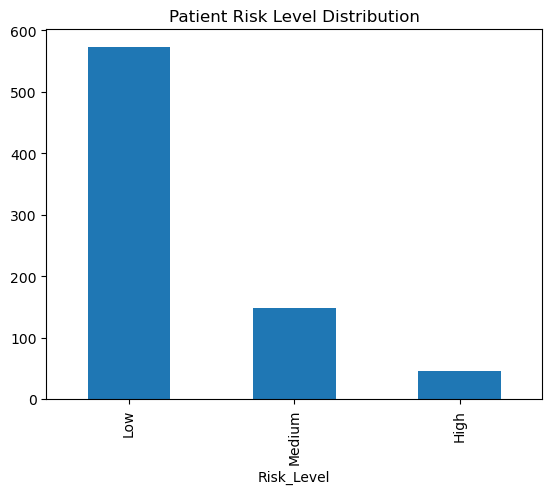

In [66]:
df['Risk_Level'].value_counts().plot(kind='bar')
plt.title('Patient Risk Level Distribution')
plt.savefig("healthcare_project/visuals/risk_distribution.png")
plt.show()

In [67]:
import os

os.listdir("healthcare_project/visuals")

['risk_distribution.png']

## Risk Level Analysis
Most patients fall into low-risk category, while a small portion identified as high-risk because of high glucose level, high BMI and age.
Patients with elevated glucose levels tend to receive higher risk scores, suggesting potential diabetes-related health concern.